<a href="https://colab.research.google.com/github/lilian662/Portafolio/blob/main/proyecto_fin_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importaciones de liverpool por medio de Web scriping

## Comparación de precios de Audifonos en temporadas de decuentos

# Extracción de Datos Liverpool


In [ ]:
!pip install matplotlip
!pip install pandas
!pip install openpyxl
!pip install selenium

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement matplotlip (from versions: none)
ERROR: No matching distribution found for matplotlip


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time
import matplotlib.pyplot as plt

In [ ]:
# === FUNCIÓN DE PRECIO DEFINITIVA ===
def precio_a_texto(producto, precio_selector="p.a-card-price"):
    try:
        precio_elem = producto.find_element(By.CSS_SELECTOR, precio_selector)

        # Precio principal
        precio_main = precio_elem.text.split("\n")[0]
        precio_main = precio_main.replace("$", "").replace(",", "").strip()

        # Centavos
        try:
            centavos_elem = precio_elem.find_element(By.TAG_NAME, "sup")
            centavos = centavos_elem.text.strip().zfill(2)
        except:
            centavos = "00"


        # Convertir a float de forma segura

        precio_float = int(precio_main) + int(centavos)
        precio_float = precio_float / 100.0


        # Formatear con separador de miles y dos decimales
        precio_texto = "${:,.2f}".format(precio_float)

        return precio_texto

    except:
        return None




# === INICIAR DRIVER ===
driver = webdriver.Chrome()
wait = WebDriverWait(driver, 20)

# LISTA FINAL
data = []

# CATEGORÍAS A SCRAPEAR
categorias = [
    {"nombre": "Audífonos", "busqueda": "audifonos", "paginas": 42},
    {"nombre": "Manos libres", "busqueda": "manos libres", "paginas": 6},
    {"nombre": "Auriculares", "busqueda": "auriculares", "paginas": 33}
]


# === SCRAPING ===
for categoria in categorias:
    print(f"\n================ SCRAPEANDO {categoria['nombre'].upper()} ================")

    for page in range(1, categoria["paginas"] + 1):
        url = f"https://www.liverpool.com.mx/tienda/page-{page}?s={categoria['busqueda']}"
        print("Entrando a:", url)
        driver.get(url)

        try:
            wait.until(EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, "ul.m-product__listingPlp > li.m-product__card")
            ))
        except:
            print("No se encontraron productos")
            continue

        products = driver.find_elements(By.CSS_SELECTOR, "ul.m-product__listingPlp > li.m-product__card")
        print("Productos encontrados:", len(products))

        for p in products:
            # MARCA
            try:
                marca = p.find_element(By.CSS_SELECTOR, "h3.a-card-brand").text
            except:
                marca = None

            # DESCRIPCIÓN
            try:
                description = p.find_element(By.CSS_SELECTOR, "h3.a-card-description").text
            except:
                try:
                    description = p.find_element(By.CSS_SELECTOR, "p.a-card-description").text
                except:
                    description = "SIN DESCRIPCIÓN"

            # PRECIOS (usando función correcta)
            precio_sin_desc = precio_a_texto(p, "p.a-card-price")
            precio_desc = precio_a_texto(p, "p.a-card-discount")

            # LINK
            try:
                url_producto = p.find_element(By.TAG_NAME, "a").get_attribute("href")
            except:
                url_producto = None

            # IMAGEN
            try:
                url_img = p.find_element(By.CSS_SELECTOR, "img").get_attribute("src")
            except:
                url_img = None

            # GUARDAR
            data.append({
                "Categoría": categoria["nombre"],
                "Marca": marca,
                "Descripción": description,
                "Precio sin descuento": precio_sin_desc,
                "Precio con descuento": precio_desc,
                "URL Producto": url_producto,
                "URL Imagen": url_img
            })


# CERRAR DRIVER
driver.quit()

# DATAFRAME
df = pd.DataFrame(data)

# ELIMINAR DUPLICADOS
df.drop_duplicates(subset="URL Producto", inplace=True)


# === FILTRO CLEAN ===
def es_valido(texto):
    if texto is None:
        return False

    texto = texto.lower()
    texto = texto.replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u")

    palabras_audio = [
        "audifono", "auricular", "auriculares",
        "headset", "diadema",
        "earbuds", "airpods", "earpods",
        "cascos", "in ear", "over ear"
    ]

    palabras_prohibidas = [
        "bocina", "speaker", "parlante",
        "convertidor", "adaptador",
        "mouse", "teclado", "monitor",
        "extractor", "campana", "cocina",
        "receptor", "transmisor", "usb", "hdmi","soporte",
        "porta","almohadilla","funda","estuche","soporte",
        "telefonos", "box", "telefono", "protector", "microfono",
        "mezcladora", "smartwatch", "base"
    ]

    if any(p in texto for p in palabras_prohibidas):
        return False

    return any(p in texto for p in palabras_audio)

df = df[df["Descripción"].apply(es_valido)]


# === GUARDAR ===
df.to_excel("audifonos_y_manos_libres_liverpool_VentaNocturna.xlsx", index=False)

print("Productos finales limpios:", len(df))


There was an error managing chromedriver (error sending request for url (https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json)); using driver found in the cache
Error sending stats to Plausible: error sending request for url (https://plausible.io/api/event)



================ SCRAPEANDO AUDÍFONOS ================
Entrando a: https://www.liverpool.com.mx/tienda/page-1?s=audifonos


WebDriverException: Message: unknown error: net::ERR_INTERNET_DISCONNECTED
  (Session info: chrome=142.0.7444.176)
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x7ff7e36ea235
	0x7ff7e3442630
	0x7ff7e31d16dd
	0x7ff7e31ce228
	0x7ff7e31beba9
	0x7ff7e31c09d7
	0x7ff7e31bf160
	0x7ff7e31be917
	0x7ff7e31be5db
	0x7ff7e31bc145
	0x7ff7e31bc9dc
	0x7ff7e31d59ea
	0x7ff7e327c8be
	0x7ff7e3252b0a
	0x7ff7e327baba
	0x7ff7e321b0ed
	0x7ff7e321bf63
	0x7ff7e3715d60
	0x7ff7e370fe8a
	0x7ff7e3731005
	0x7ff7e345d71e
	0x7ff7e3464e1f
	0x7ff7e344b7c4
	0x7ff7e344b97f
	0x7ff7e34318e8
	0x7ffb847ce8d7
	0x7ffb84d6c53c


In [ ]:
# ==========================
# CARGAR ARCHIVO
# ==========================
# ---Venta Nocturna ----
# 07 de Diciembre de 2025
archivo = "audifonos_y_manos_libres_liverpool_VentaNocturna.xlsx"
df = pd.read_excel(archivo)

# ---BlackFriday ----
# 28 de Noviembre de 2025
archivo2 = "audifonos_y_manos_libres_liverpool_blackfriday.xlsx"
df2 = pd.read_excel(archivo2)

# ---Normal ----
# 20 de Noviembre de 2025
archivo3 = "audifonos_y_manos_libres_liverpool_limpiobueno (1) (1).xlsx"
df3 = pd.read_excel(archivo3)

In [ ]:
# ==========================
# LIMPIEZA DE PRECIOS
# ==========================
def limpiar_precio(col):
    col = col.astype(str)
    col = col.str.replace("$","", regex=False)
    col = col.str.replace(",","", regex=False)
    col = col.replace("nan", None)
    return col.astype(float)

df["Precio sin descuento"] = limpiar_precio(df["Precio sin descuento"])
df["Precio con descuento"] = limpiar_precio(df["Precio con descuento"])

# ==========================
# ELIMINAR SIN MARCA
# ==========================
df = df.dropna(subset=["Marca"])

#-----------------------------------------------------------------------------

df2["Precio sin descuento"] = limpiar_precio(df2["Precio sin descuento"])
df2["Precio con descuento"] = limpiar_precio(df2["Precio con descuento"])

# ==========================
# ELIMINAR SIN MARCA
# ==========================
df2 = df2.dropna(subset=["Marca"])

#-----------------------------------------------------------------------------

df3["Precio sin descuento"] = limpiar_precio(df3["Precio sin descuento"])
df3["Precio con descuentoantes"] = limpiar_precio(df3["Precio con descuentoantes"])

# ==========================
# ELIMINAR SIN MARCA
# ==========================
df3 = df3.dropna(subset=["Marca"])


In [ ]:
# ==========================
# LIMPIAR DATOS
# ==========================

#Eliminamos todos aquellos datos que tengan datos nulos en el precio

df = df[pd.to_numeric(df['Precio sin descuento'], errors='coerce').notnull()]
df2 = df2[pd.to_numeric(df2['Precio sin descuento'], errors='coerce').notnull()]
df3 = df3[pd.to_numeric(df3['Precio sin descuento'], errors='coerce').notnull()]


In [ ]:
# COMPARACIÓN DE PRECIOS
Antes = df3
Black = df2
Nocturna = df

#Renombramos columnas
Antes = Antes.rename(columns={"Precio con descuentoantes": "Antes"})
Black = Black.rename(columns={"Precio con descuento":"BlackFriday"})
Nocturna = Nocturna.rename(columns={"Precio con descuento":"Nocturna"})


# Cambia este nombre si tu columna se llama distinto
clav = "URL Producto"
clav1="Marca"

# ELIMINAR DUPLICADOS
Antes = Antes.drop_duplicates(subset=[clav])
Black = Black.drop_duplicates(subset=[clav])
Nocturna = Nocturna.drop_duplicates(subset=[clav])

#Unimos
Union1 = pd.merge(
    Antes[[clav, "Antes"]],
    Black[[clav, "BlackFriday"]],
    on=clav,
    how="outer"
)

# Unir el resultado con Nocturna
Union = pd.merge(
    Union1,
    Nocturna[[clav, "Nocturna"]],
    on=clav,
    how="outer"
)

# Limpiamos los datos
Union = Union[pd.to_numeric(Union['Antes'], errors='coerce').notnull()]

#print(Union)

In [ ]:
# =============================
#  AGOTADOS
# =============================

Union["Estado"] = "Disponible"
Union.loc[Union["BlackFriday"].isna(), "Estado"] = "Agotado"
Union.loc[Union["Nocturna"].isna(), "Estado"] = "Agotado"

print(Union)


                                           URL Producto   Antes  BlackFriday  \
0     https://www.liverpool.com.mx/tienda/pdp/apple-...  548.98       548.98   
2     https://www.liverpool.com.mx/tienda/pdp/aud%C3...  697.24       697.24   
3     https://www.liverpool.com.mx/tienda/pdp/aud%C3...  610.08       610.08   
4     https://www.liverpool.com.mx/tienda/pdp/aud%C3...  755.00       755.00   
5     https://www.liverpool.com.mx/tienda/pdp/aud%C3...  681.54       681.54   
...                                                 ...     ...          ...   
1651  https://www.liverpool.com.mx/tienda/pdp/set-de...  389.00       389.00   
1652  https://www.liverpool.com.mx/tienda/pdp/set-de...  749.00       749.00   
1653  https://www.liverpool.com.mx/tienda/pdp/set-de...  749.00       749.00   
1655  https://www.liverpool.com.mx/tienda/pdp/set-de...  599.00       559.00   
1656  https://www.liverpool.com.mx/tienda/pdp/set-de...  739.00       699.00   

      Nocturna      Estado  
0       54

In [ ]:
# =============================
# COMPARACIÓN
# =============================

# Vemos si hubo algun descuento durante la venta
Union["BlackFriday_Dif"] = Union["Antes"] - Union["BlackFriday"]
Union["Nocturna_Dif"] = Union["Antes"] - Union["Nocturna"]

Union["Black_%"] = (Union["BlackFriday_Dif"] / Union["Antes"]) * 100
Union["Nocturna_%"] = (Union["Nocturna_Dif"] / Union["Antes"]) * 100


# =============================
#  CLASIFICAR LOS DESCUENTOS
# =============================
def clasificar(x):
    if pd.isna(x):
        return "Agotado"
    elif x > 5:
        return "Descuento real"
    elif x < -5:
        return "Subió precio"
    else:
        return "Sin cambio"

Union["Resultado"] = Union["Black_%"].apply(clasificar)
Union["Resultado2"] = Union["Nocturna_%"].apply(clasificar)

Union.to_excel("Comparaciones.xlsx", index=False)

#print(Union)

C:\Users\HUAWEII\AppData\Local\Temp\ipykernel_15404\1705053929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com["ID"] = range(1, len(com) +1)


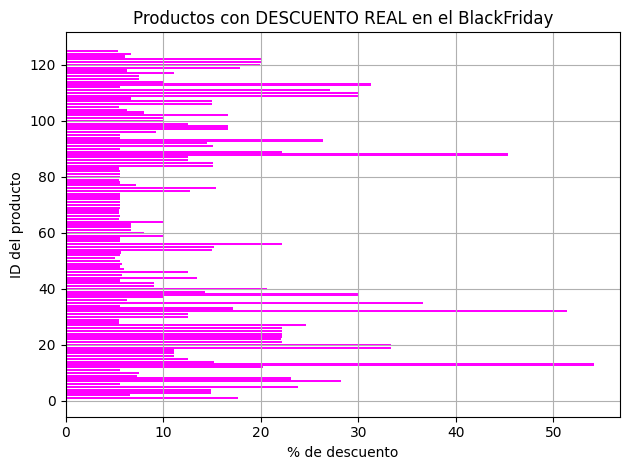

In [ ]:
com = Union[Union["Resultado"]== "Descuento real"]
com["ID"] = range(1, len(com) +1)

plt.figure()
plt.barh(com["ID"], com["Black_%"], color = "magenta")
plt.title("Productos con DESCUENTO REAL en el BlackFriday")
plt.xlabel("% de descuento")
plt.ylabel("ID del producto")
plt.tight_layout()
plt.grid()
plt.show()

C:\Users\HUAWEII\AppData\Local\Temp\ipykernel_15404\183282689.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com["ID"] = range(1, len(com) +1)


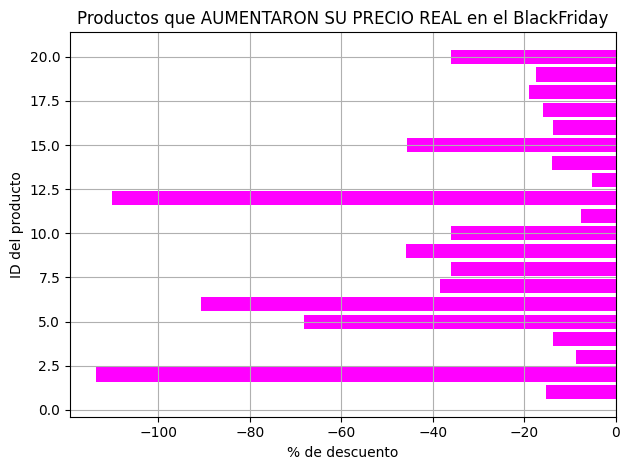

In [ ]:
com = Union[Union["Resultado"]== "Subió precio"]
com["ID"] = range(1, len(com) +1)

plt.figure()
plt.barh(com["ID"], com["Black_%"], color = "magenta")
plt.title("Productos que AUMENTARON SU PRECIO REAL en el BlackFriday")
plt.xlabel("% de descuento")
plt.ylabel("ID del producto")
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
# Marcas que inflaron más sus precios
marc = com[com['Black_%'] < -60]
print(len(marc))
marc

completo = com.merge(df2[['URL Producto', 'Marca']], on='URL Producto', how='left')
marc = completo[completo['Black_%'] < -60]
print(marc[['URL Producto', 'Marca', 'Black_%']])

4
                                         URL Producto     Marca     Black_%
1   https://www.liverpool.com.mx/tienda/pdp/aud%C3...    HYPERX -113.591032
4   https://www.liverpool.com.mx/tienda/pdp/aud%C3...  Genérica  -68.126582
5   https://www.liverpool.com.mx/tienda/pdp/aud%C3...    BINDEN  -90.678604
11  https://www.liverpool.com.mx/tienda/pdp/aud%C3...     AKANE -110.183639


C:\Users\HUAWEII\AppData\Local\Temp\ipykernel_15404\1736202800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com1["ID"] = range(1, len(com1) +1)


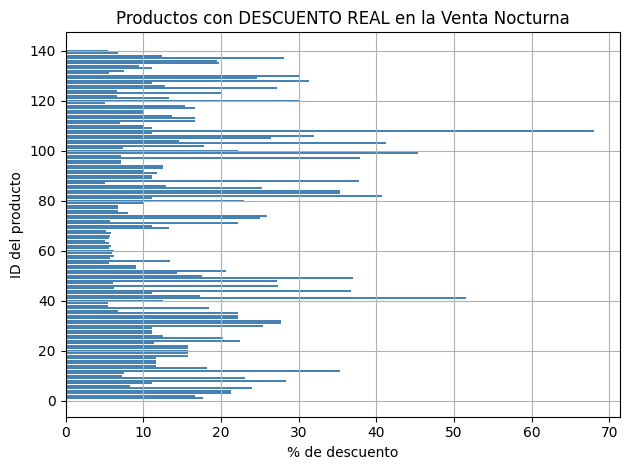

In [ ]:
com1 = Union[Union["Resultado2"]== "Descuento real"]
com1["ID"] = range(1, len(com1) +1)

plt.figure()
plt.barh(com1["ID"], com1["Nocturna_%"], color = "steelblue")
plt.title("Productos con DESCUENTO REAL en la Venta Nocturna")
plt.xlabel("% de descuento")
plt.ylabel("ID del producto")
plt.tight_layout()
plt.grid()
plt.show()

C:\Users\HUAWEII\AppData\Local\Temp\ipykernel_15404\1108071302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com1["ID"] = range(1, len(com1) +1)


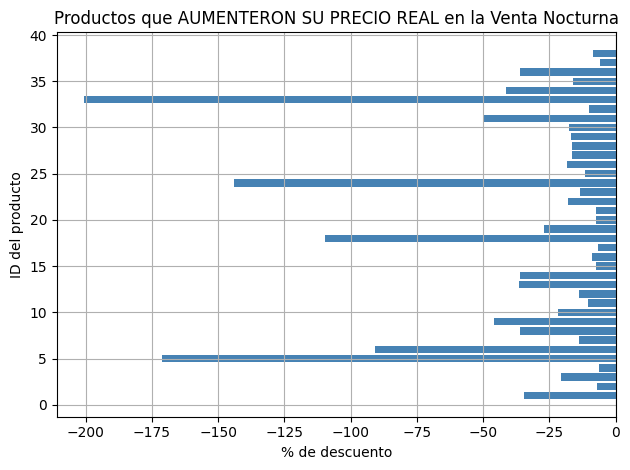

In [ ]:
com1 = Union[Union["Resultado2"]== "Subió precio"]
com1["ID"] = range(1, len(com1) +1)

plt.figure()
plt.barh(com1["ID"], com1["Nocturna_%"], color = "steelblue")
plt.title("Productos que AUMENTERON SU PRECIO REAL en la Venta Nocturna")
plt.xlabel("% de descuento")
plt.ylabel("ID del producto")
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
# Marcas que inflaron más sus precios
marc = com1[com1['Nocturna_%'] < -100]
print(len(marc))

completo = com1.merge(df[['URL Producto', 'Marca']], on='URL Producto', how='left')
marc = completo[completo['Nocturna_%'] < -100]
print(marc[['URL Producto', 'Marca', 'Nocturna_%']])



4
                                         URL Producto      Marca  Nocturna_%
4   https://www.liverpool.com.mx/tienda/pdp/aud%C3...      TRUST -171.060449
17  https://www.liverpool.com.mx/tienda/pdp/aud%C3...      AKANE -109.849750
23  https://www.liverpool.com.mx/tienda/pdp/aud%C3...  RED LEMON -143.902439
32  https://www.liverpool.com.mx/tienda/pdp/aud%C3...   Genérica -200.864445


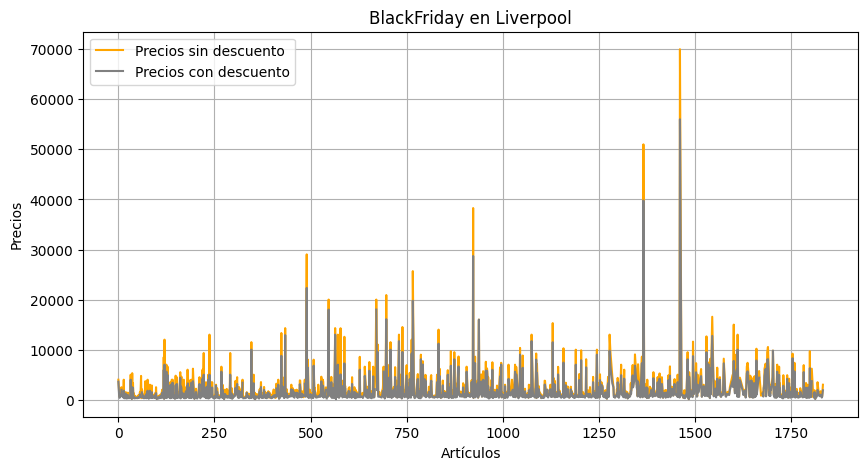

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df2['Precio sin descuento'], label="Precios sin descuento", linestyle='-', c="orange")

plt.plot(df2['Precio con descuento'], label="Precios con descuento", linestyle='-', c="grey")

plt.xlabel('Artículos')
plt.ylabel('Precios')
plt.title('BlackFriday en Liverpool')

plt.legend()         # <-- Muestra la leyenda
plt.grid(True)
plt.show()

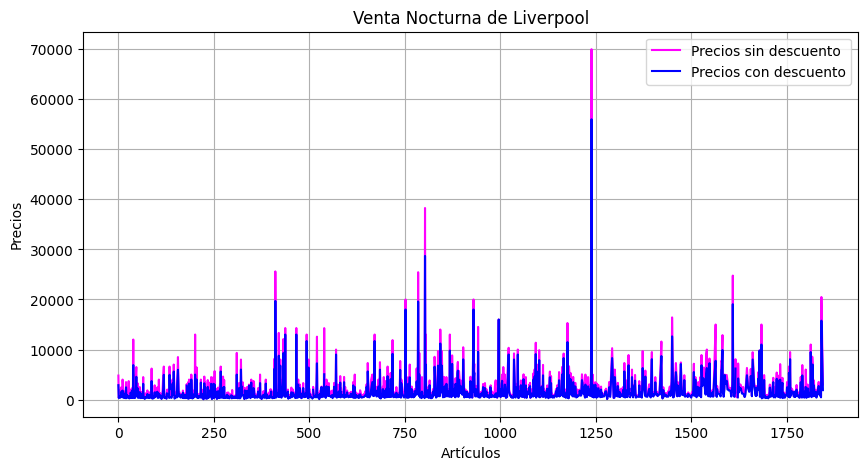

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df['Precio sin descuento'], label="Precios sin descuento", linestyle='-', c="magenta")

plt.plot(df['Precio con descuento'], label="Precios con descuento", linestyle='-', c="blue")

plt.xlabel('Artículos')
plt.ylabel('Precios')
plt.title('Venta Nocturna de Liverpool')

plt.legend()         # <-- Muestra la leyenda
plt.grid(True)
plt.show()


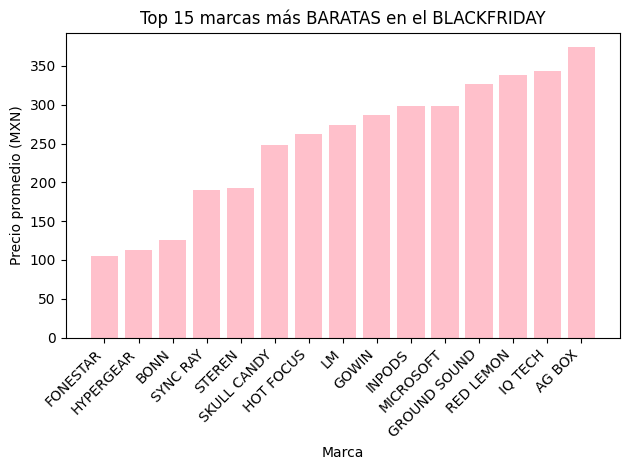

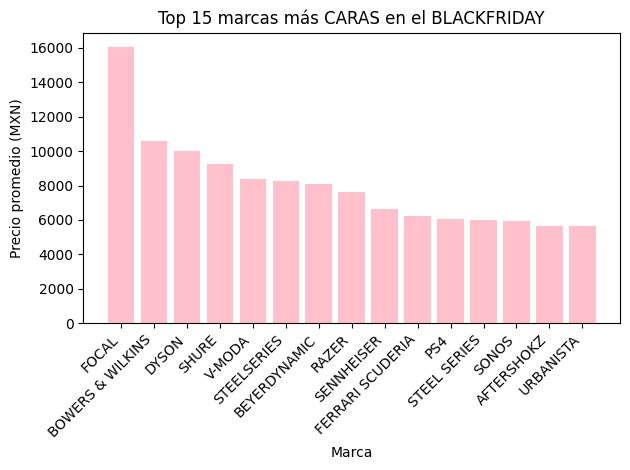

MARCAS ANALIZADAS: 212

TOP 15 BARATAS:
             Marca    Con_desc   Tipo descuento
60       FONESTAR  105.000000  Descuento real 
84      HYPERGEAR  112.460000  Descuento real 
33           BONN  125.260000      Sin cambio 
185      SYNC RAY  190.000000  Descuento real 
180        STEREN  193.000000  Descuento real 
170   SKULL CANDY  248.340000  Descuento real 
81      HOT FOCUS  262.500000  Descuento real 
114            LM  274.000000  Descuento real 
72          GOWIN  287.200000  Descuento real 
89         INPODS  299.000000  Descuento real 
121     MICROSOFT  299.000000  Descuento real 
74   GROUND SOUND  326.821053  Descuento real 
156     RED LEMON  338.000000  Descuento real 
90        IQ TECH  344.000000  Descuento real 
6          AG BOX  374.000000  Descuento real 

TOP 15 CARAS:
                 Marca      Con_desc   Tipo descuento
59              FOCAL  16076.250000  Descuento real 
35   BOWERS & WILKINS  10610.244444  Descuento real 
49              DYSON   9999.000

In [ ]:
#BLACKFRIDAY

# ==========================
# RESUMEN POR MARCA
# ==========================
resumen1 = df2.groupby("Marca").agg(
    Productos=("Marca", "count"),
    Sin_desc=("Precio sin descuento", "mean"),
    Con_desc=("Precio con descuento", "mean")
).reset_index()

# MÉTRICAS
resumen1["Diferencia"] = resumen1["Sin_desc"] - resumen1["Con_desc"]
resumen1["Cambio_%"] = (resumen1["Diferencia"] / resumen1["Sin_desc"]) * 100

# CLASIFICAR DESCUENTOS
def clasificar(x):
    if x > 5:
        return "Descuento real "
    elif x < -5:
        return "Descuento falso "
    else:
        return "Sin cambio "

resumen1["Tipo descuento"] = resumen1["Cambio_%"].apply(clasificar)


resumen1["Tipo descuento"] = resumen1["Cambio_%"].apply(clasificar)

# ORDENAR POR PRECIO
top_baratas1 = resumen1.sort_values("Con_desc").head(15)
top_caras1= resumen1.sort_values("Con_desc", ascending=False).head(15)

# GRÁFICAS

# TOP 15 BARATAS
plt.figure()
plt.bar(top_baratas1["Marca"], top_baratas1["Con_desc"], color="pink")
plt.title("Top 15 marcas más BARATAS en el BLACKFRIDAY") #precio promedio con descuento
plt.xlabel("Marca")
plt.ylabel("Precio promedio (MXN)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# TOP 15 CARAS
plt.figure()
plt.bar(top_caras1["Marca"], top_caras1["Con_desc"], color="pink")
plt.title("Top 15 marcas más CARAS en el BLACKFRIDAY")       # precio promedio con descuento
plt.xlabel("Marca")
plt.ylabel("Precio promedio (MXN)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#top_baratas.to_excel("top15_marcas_baratas.xlsx", index=False)
#top_caras.to_excel("top15_marcas_caras.xlsx", index=False)
#resumen.to_excel("resumen_marcas_completo.xlsx", index=False)

# IMPRIMIR RESULTADOS
print("MARCAS ANALIZADAS:", len(resumen1))
print("\nTOP 15 BARATAS:\n", top_baratas1[["Marca","Con_desc","Tipo descuento"]])
print("\nTOP 15 CARAS:\n", top_caras1[["Marca","Con_desc","Tipo descuento"]])

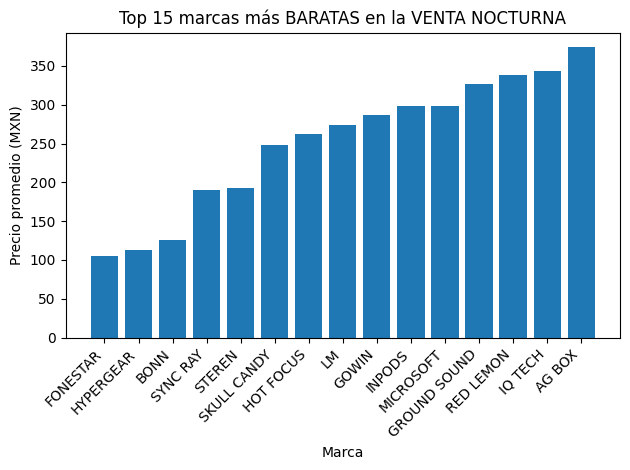

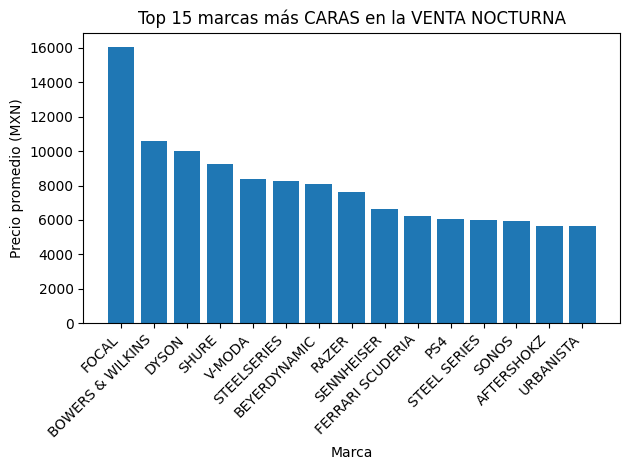

MARCAS ANALIZADAS: 212

TOP 15 BARATAS:
             Marca    Con_desc   Tipo descuento
60       FONESTAR  105.000000  Descuento real 
84      HYPERGEAR  112.460000  Descuento real 
33           BONN  125.260000      Sin cambio 
185      SYNC RAY  190.000000  Descuento real 
180        STEREN  193.000000  Descuento real 
170   SKULL CANDY  248.340000  Descuento real 
81      HOT FOCUS  262.500000  Descuento real 
114            LM  274.000000  Descuento real 
72          GOWIN  287.200000  Descuento real 
89         INPODS  299.000000  Descuento real 
121     MICROSOFT  299.000000  Descuento real 
74   GROUND SOUND  326.821053  Descuento real 
156     RED LEMON  338.000000  Descuento real 
90        IQ TECH  344.000000  Descuento real 
6          AG BOX  374.000000  Descuento real 

TOP 15 CARAS:
                 Marca      Con_desc   Tipo descuento
59              FOCAL  16076.250000  Descuento real 
35   BOWERS & WILKINS  10610.244444  Descuento real 
49              DYSON   9999.000

In [ ]:
#VENTA NOCTURNA

# ==========================
# RESUMEN POR MARCA
# ==========================
resumen = df.groupby("Marca").agg(
    Productos=("Marca", "count"),
    Sin_desc=("Precio sin descuento", "mean"),
    Con_desc=("Precio con descuento", "mean")
).reset_index()

# MÉTRICAS
resumen["Diferencia"] = resumen["Sin_desc"] - resumen["Con_desc"]
resumen["Cambio_%"] = (resumen["Diferencia"] / resumen["Sin_desc"]) * 100

# CLASIFICAR DESCUENTOS
def clasificar(x):
    if x > 5:
        return "Descuento real "
    elif x < -5:
        return "Descuento falso "
    else:
        return "Sin cambio "

resumen["Tipo descuento"] = resumen["Cambio_%"].apply(clasificar)


resumen["Tipo descuento"] = resumen["Cambio_%"].apply(clasificar)

# ORDENAR POR PRECIO
top_baratas = resumen.sort_values("Con_desc").head(15)
top_caras = resumen.sort_values("Con_desc", ascending=False).head(15)

# GRÁFICAS

# TOP 15 BARATAS
plt.figure()
plt.bar(top_baratas["Marca"], top_baratas["Con_desc"])
plt.title("Top 15 marcas más BARATAS en la VENTA NOCTURNA") #precio promedio con descuento
plt.xlabel("Marca")
plt.ylabel("Precio promedio (MXN)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# TOP 15 CARAS
plt.figure()
plt.bar(top_caras["Marca"], top_caras["Con_desc"])
plt.title("Top 15 marcas más CARAS en la VENTA NOCTURNA")       # precio promedio con descuento
plt.xlabel("Marca")
plt.ylabel("Precio promedio (MXN)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#top_baratas.to_excel("top15_marcas_baratas.xlsx", index=False)
#top_caras.to_excel("top15_marcas_caras.xlsx", index=False)
#resumen.to_excel("resumen_marcas_completo.xlsx", index=False)

# IMPRIMIR RESULTADOS
print("MARCAS ANALIZADAS:", len(resumen))
print("\nTOP 15 BARATAS:\n", top_baratas[["Marca","Con_desc","Tipo descuento"]])
print("\nTOP 15 CARAS:\n", top_caras[["Marca","Con_desc","Tipo descuento"]])